In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

Menampilkan Citra Backup

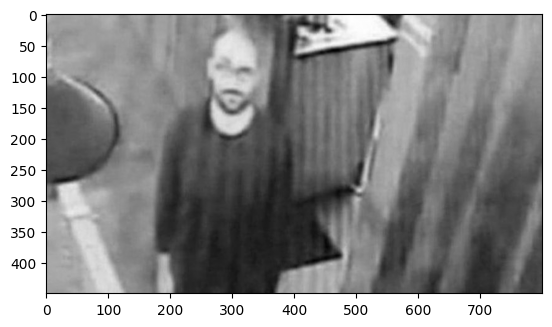

In [3]:
backup = plt.imread('backup.jpg')

backup_gray = cv.cvtColor(backup, cv.COLOR_RGB2GRAY)

plt.imshow(backup_gray, cmap = 'gray')

SMOOTHING, SHARPENING, DAN KOMBINASI KEDUANYA

Perbedaan dari ketiga metode yaitu pada citra yang dihasilkan oleh smoothing, citra tampak lebih mulus, sedangkan dengan sharpening, citra tampak lebih tajam dibanding dengan smoothing. Sedangkan gabungan keduanya menghasilkan hasil citra yang buram namun lebih tajam dari pada hasil smoothing saja.

Perbedaan mean, median dan modus yaitu mean digunakan untuk melakukan bluring, median digunakan untuk menghilangkan noise yang efektif dan modus digunakan jika ingin membuat warna dominan menjadi lebih merata.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

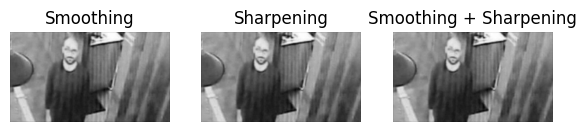

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img. shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np. array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

smoothing = convolution(backup_gray, kernelSmoothing)
sharpening = convolution(backup_gray, kernelSharpening)
kombinasi = smoothing + sharpening

plt.figure(figsize=(7, 10))

plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap='gray')
plt.title("Smoothing")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.title("Sharpening")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(kombinasi, cmap='gray')
plt.title("Smoothing + Sharpening")
plt.axis("off")

DETEKSI TEPI DAN KOMBINASI OPERATOR

Operator digunakan untuk mendeteksi tepi pada citra sedangkan kombinasi operator menghasilkan deteksi citra yang lebih jelas dibanding yang menggunakan satu operator saja.

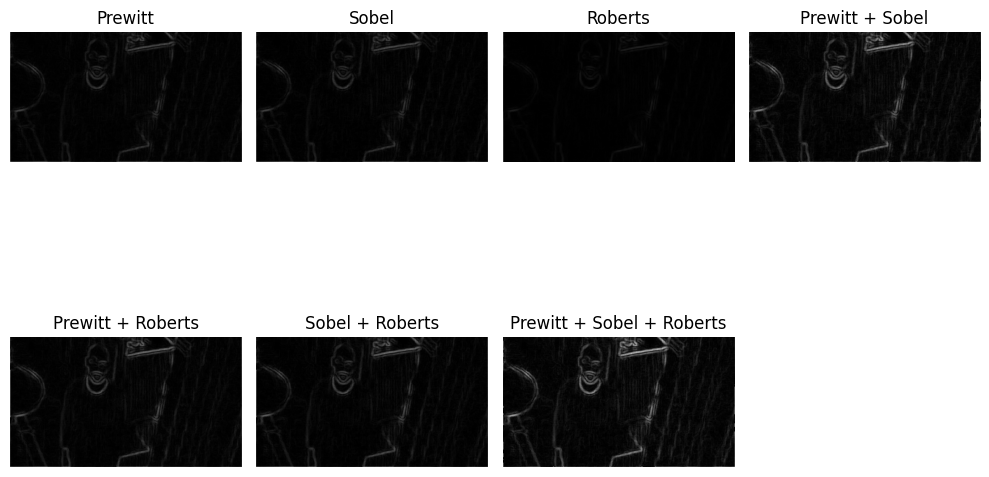

In [7]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np. zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def normalisasi(image):
    img = image.astype(float)
    return (img - img.min()) / (img.max() - img.min())

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)


prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np. float32)

prewittY = np.array([
    [ 1, 1, 1],
    [ 0, 0, 0],
    [-1, -1, -1]
], dtype=np. float32)


robertsX = np.array([
    [ 1, 0],
    [ 0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [ -1, 0]
], dtype=np. float32)

prewitt = edge(backup_gray, prewittX, prewittY)
sobel = edge(backup_gray, sobelX, sobelY)
roberts = edge(backup_gray, robertsX, robertsY)

preSo = prewitt + sobel
preRo = prewitt + roberts
soRo = sobel + roberts
preSoRo = prewitt + sobel + roberts

preSo_norma = normalisasi(preSo)
preRo_norma = normalisasi(preRo)
soRo_norma = normalisasi(soRo)
preSoRo_norma = normalisasi(preSoRo)

plt.figure(figsize=(10, 7))

plt.subplot(2, 4, 1)
plt.imshow(prewitt, cmap = 'gray')
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(sobel, cmap = 'gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(roberts, cmap = 'gray')
plt.title("Roberts")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(preSo_norma, cmap = 'gray')
plt.title("Prewitt + Sobel")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(preRo_norma, cmap = 'gray')
plt.title("Prewitt + Roberts")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(soRo_norma, cmap = 'gray')
plt.title("Sobel + Roberts")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(preSoRo_norma, cmap = 'gray')
plt.title("Prewitt + Sobel + Roberts")
plt.axis("off")

plt.tight_layout()
plt.show()

PERBANDINGAN THRESHOLD TEPI

Penggunaan threshold membuat tepi citra menjadi lebih terlihat dengan jelas, mengetahui setiap tepi yang terlihat berdasarkan nilai ambang yang di tentukan.

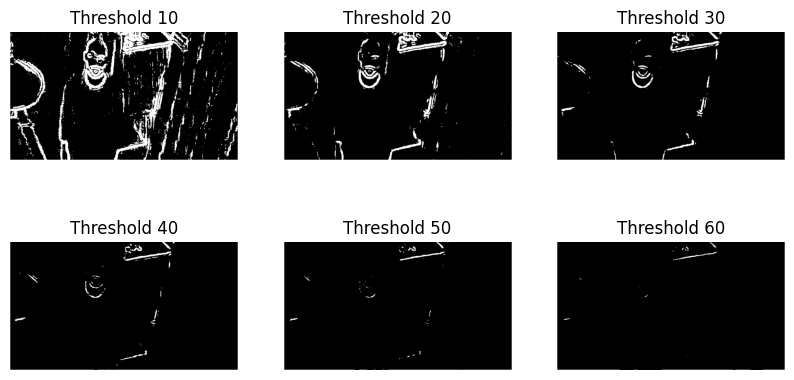

In [31]:
def threshold(img, thres):
    return (img > thres).astype(np.uint8)*255

plt.figure(figsize=(10,5))

thres10 = threshold(prewitt, 10)
thres20 = threshold(prewitt, 20)
thres30 = threshold(prewitt, 30)
thres40 = threshold(prewitt, 40)
thres50 = threshold(prewitt, 50)
thres60 = threshold(prewitt, 60)

plt.subplot(2,3,1)
plt.imshow(thres10, cmap='gray')
plt.title("Threshold 10")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(thres20, cmap='gray')
plt.title("Threshold 20")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(thres30, cmap='gray')
plt.title("Threshold 30")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(thres40, cmap='gray')
plt.title("Threshold 40")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(thres50, cmap='gray')
plt.title("Threshold 50")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(thres60, cmap='gray')
plt.title("Threshold 60")
plt.axis('off')

plt.show()

HIGHLIGHT SILUET ORANG

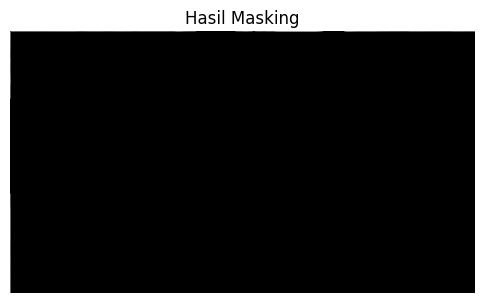

In [29]:
height, width = backup_gray. shape
hasil_masking = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        nilai_pixel = roberts[i, j]

        if nilai_pixel < 120:
            hasil_masking[i, j] = 0
        else:
            hasil_masking[i, j] = backup_gray[i, j]

plt.figure(figsize=(6,6))
plt.imshow(hasil_masking, cmap='gray')
plt.title("Hasil Masking")
plt.axis('off')
plt.show()

In [35]:
_, thresh = cv.threshold(backup_gray, 120, 255, cv.THRESH_BINARY)

highlight = backup_gray.copy()

highlight[thresh == 255] = [255, 255, 0]

hasil = cv.addWeighted(img_rgb, 0.7, highlight, 0.3, 0)

contours, _ = cv.findContours(
    thresh,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

cv.drawContours(hasil, contours, -1, (255,255,0), 2)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thresh, cmap='gray')
plt.title('Masking')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil)
plt.title('Highlight Siluet Orang')
plt.axis('off')

plt.show()

ValueError: NumPy boolean array indexing assignment cannot assign 3 input values to the 195163 output values where the mask is true

DETEKSI TEPI DAN BACKGROUND REMOVAL

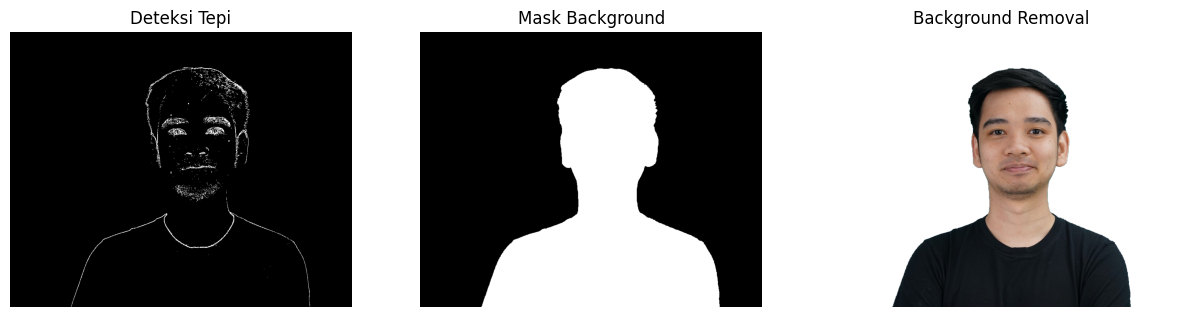

In [47]:
david = plt.imread('david.jpg')

height, width, channel = david.shape
david_gray = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        r = int(david[i, j, 0])
        g = int(david[i, j, 1])
        b = int(david[i, j, 2])
        gray_val = (r + g + b) // 3
        david_gray[i, j] = gray_val
edge = np.zeros((height, width), dtype=np.uint8)

for i in range(height - 1):
    for j in range(width - 1):
        gx = abs(int(david_gray[i, j]) - int(david_gray[i, j+1]))
        gy = abs(int(david_gray[i, j]) - int(david_gray[i+1, j]))
        total = gx + gy
        if total > 30:
            edge[i, j] = 255
        else:
            edge[i, j] = 0
mask = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        r = int(david[i, j, 0])
        g = int(david[i, j, 1])
        b = int(david[i, j, 2])
        if g > r + 30 and b > r + 30:
            mask[i, j] = 0
        else:
            mask[i, j] = 255
hasil = np.zeros((height, width, 3), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        if mask[i, j] == 255:
            hasil[i, j, 0] = david[i, j, 0]
            hasil[i, j, 1] = david[i, j, 1]
            hasil[i, j, 2] = david[i, j, 2]
        else:
            hasil[i, j] = [255,255,255]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(edge, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title('Mask Background')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil)
plt.title('Background Removal')
plt.axis('off')

plt.show()